In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
df_original = pd.read_stata("Mexico-2023-full-data.dta")

cols = {
    "d2": "sales",
    "l1": "employees",     
    "b5": "start_year",
    "l10": "training",
    "k82": "financing",
    "d3c": "export_share"
}

df = df_original[list(cols.keys())].copy()
df.rename(columns=cols, inplace=True)

In [60]:
# Convertir columnas numéricas principales
for col in ["sales", "employees", "start_year", "export_share"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Mapear Yes/No (si aplica) y convertir a numérico
yes_no_map = {"Yes": 1, "No": 0, "YES": 1, "NO": 0}
for col in ["training", "financing"]:
    df[col] = df[col].replace(yes_no_map)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Exportador binario
df["exporter"] = (df["export_share"] > 0).astype(int)

# Edad empresa
SURVEY_YEAR = 2023
df["age"] = SURVEY_YEAR - df["start_year"]

# Productividad laboral
df["labor_prod"] = df["sales"] / df["employees"]

# Log ventas (para reducir outliers)
df["log_sales"] = np.log(df["sales"])

# Columnas mínimas para que el modelo tenga sentido
keep_cols = ["sales", "employees", "start_year", "training", "financing", "export_share",
             "exporter", "age", "labor_prod", "log_sales"]

df_final = df[keep_cols].dropna().copy()

df_final = df_final[
    (df_final["sales"] > 0) &
    (df_final["employees"] > 0) &
    (df_final["age"] >= 0) &
    (df_final["labor_prod"] > 0)
].copy()

print("Dataset limpio:", df_final.shape)
df_final.head()

Dataset limpio: (267, 10)


C:\Users\angel\AppData\Local\Temp\ipykernel_21180\2154121866.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(yes_no_map)
C:\Users\angel\AppData\Local\Temp\ipykernel_21180\2154121866.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[col] = df[col].replace(yes_no_map)


,sales,employees,start_year,training,financing,export_share,exporter,age,labor_prod,log_sales
16,3600000,5,1985.0,0,0.0,0,0,38.0,720000.0,15.096444
22,6000000,6,2000.0,0,0.0,0,0,23.0,1000000.0,15.607270
28,6980000,8,2008.0,1,0.0,0,0,15.0,872500.0,15.758559
39,6000000,15,2011.0,0,0.0,0,0,12.0,400000.0,15.607270
46,11300000,10,2003.0,0,0.0,0,0,20.0,1130000.0,16.240313


In [61]:
X_sales = df_final[["employees", "age", "training", "financing", "exporter"]]
y_sales = df_final["log_sales"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sales, y_sales, test_size=0.2, random_state=42
)

model_sales = LinearRegression()
model_sales.fit(X_train, y_train)

y_pred = model_sales.predict(X_test)

print("=== MODELO VENTAS (log_sales) ===")
print("Coeficientes:")
for var, coef in zip(X_sales.columns, model_sales.coef_):
    print(f"{var}: {coef:.4f}")

print(f"Intercepto: {model_sales.intercept_:.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

=== MODELO VENTAS (log_sales) ===
Coeficientes:
employees: 0.0141
age: 0.0038
training: 0.3850
financing: 0.0000
exporter: 0.0000
Intercepto: 15.5478
R2: 0.6629
MSE: 0.7791


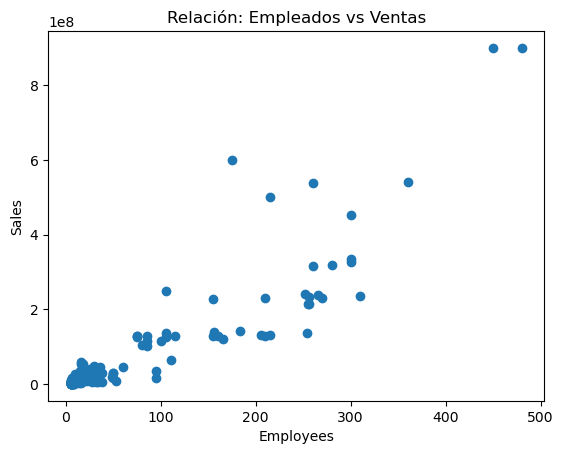

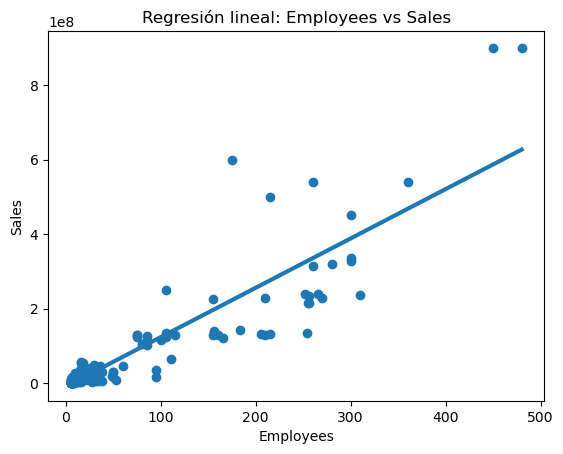

In [63]:
X = df_final["employees"].values
Y = df_final["sales"].values

plt.scatter(X, Y)
plt.xlabel("Employees")
plt.ylabel("Sales")
plt.title("Relación: Empleados vs Ventas")
plt.show()

X2 = df_final[["employees"]].values
model = LinearRegression()
model.fit(X2, Y)

Y_pred = model.predict(X2)

idx = np.argsort(X2[:,0])

plt.scatter(X2[idx,0], Y[idx])
plt.plot(X2[idx,0], Y_pred[idx], linewidth=3)
plt.xlabel("Employees")
plt.ylabel("Sales")
plt.title("Regresión lineal: Employees vs Sales")
plt.show()

## Conclusion
El modelo muestra que el tamaño de la empresa (employees) y la capacitación del personal (training) son los principales factores que explican el nivel de ventas. Las empresas más grandes tienden a registrar mayores ventas, mientras que la capacitación formal se asocia con un mejor desempeño empresarial. La edad de la empresa también presenta un efecto positivo, aunque menor. El modelo explica aproximadamente el 66% de la variabilidad en las ventas (R² ≈ 0.66), lo que representa un buen ajuste para datos empresariales. El acceso a financiamiento y la condición exportadora muestran un efecto reducido en esta muestra, posiblemente debido a baja variabilidad en estas variables.